## 1. Загрузка библиотек и данных

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)

# Настройки отображения
pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid')

data = pd.read_csv("horse_colic_normalized.csv")

df_reduced = pd.read_csv(
    "horse_colic_reduced_encoded.csv",
    delimiter=","
)

target_col = "outcome"

print('Размер датасета:', data.shape)
print('\nПервые 5 строк:')
display(data.head())

Размер датасета: (368, 28)

Первые 5 строк:


,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,pain,peristalsis,abdominal_distension,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_examination_feces,abdomen,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,5.0,4.0,4.0,NaN,NaN,NaN,3.0,5.0,45.0,8.4,NaN,NaN,2.0,11300,0,0,2,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,3.0,4.0,2.0,NaN,NaN,NaN,4.0,2.0,50.0,85.0,2.0,2.0,3.0,2208,0,0,2,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,3.0,3.0,1.0,NaN,NaN,NaN,1.0,1.0,33.0,6.7,NaN,NaN,1.0,0,0,0,1,2
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,2.0,4.0,4.0,1.0,2.0,5.0,3.0,NaN,48.0,7.2,3.0,5.3,2.0,2208,0,0,1,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.0,7.4,NaN,NaN,2.0,4300,0,0,2,2


## 2. Анализ полученной выборки

In [13]:
print('\nКоличество пропусков по столбцам:')
missing_values = data.isnull().sum()
display(missing_values.to_frame(name='Количество пропусков'))

print('\nСтатистическое описание данных:')
display(data.describe().T)


Количество пропусков по столбцам:


,Количество пропусков
surgery,2
age,0
hospital_number,0
rectal_temperature,69
pulse,26
respiratory_rate,71
temperature_of_extremities,65
peripheral_pulse,83
mucous_membranes,48
capillary_refill_time,38



Статистическое описание данных:


,count,mean,std,min,25%,50%,75%,max
surgery,366.0,1.415301e+00,4.934484e-01,1.0,1.00,1.0,2.0,2.0
age,368.0,1.608696e+00,2.123985e+00,1.0,1.00,1.0,1.0,9.0
hospital_number,368.0,1.112334e+06,1.560122e+06,514279.0,528915.25,530299.0,534727.5,5305629.0
rectal_temperature,299.0,3.813445e+01,7.116839e-01,35.4,37.80,38.1,38.5,40.8
pulse,342.0,7.075731e+01,2.808987e+01,30.0,48.00,60.0,88.0,184.0
respiratory_rate,297.0,3.052189e+01,1.766965e+01,8.0,18.00,28.0,36.0,96.0
temperature_of_extremities,303.0,2.356436e+00,1.041371e+00,1.0,1.00,3.0,3.0,4.0
peripheral_pulse,285.0,1.961404e+00,1.052454e+00,1.0,1.00,1.0,3.0,4.0
mucous_membranes,320.0,2.834375e+00,1.591732e+00,1.0,1.00,3.0,4.0,6.0
capillary_refill_time,330.0,1.303030e+00,4.732895e-01,1.0,1.00,1.0,2.0,3.0


Распределение целевой переменной outcome:


,Количество объектов
outcome,
1.0,225
2.0,89
3.0,52


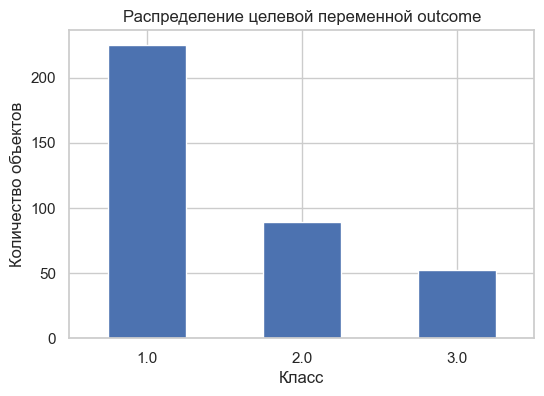

Доли классов:


,"Доля, %"
outcome,
1.0,61.48
2.0,24.32
3.0,14.21


In [14]:
print(f'Распределение целевой переменной {target_col}:')

class_distribution = data[target_col].value_counts().sort_index()

display(class_distribution.to_frame(name='Количество объектов'))

plt.figure(figsize=(6, 4))

class_distribution.plot(kind='bar')

plt.title(f'Распределение целевой переменной {target_col}')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)

plt.show()

print('Доли классов:')

display(
    (data[target_col].value_counts(normalize=True).sort_index() * 100)
    .round(2)
    .to_frame(name='Доля, %')
)

## 3. Подготовка признаков и разделение на обучающую и тестовую выборки

In [15]:
data = data.dropna(subset=[target_col])
df_reduced = df_reduced.dropna(subset=[target_col])

X = data.drop(target_col, axis=1)
y = data[target_col]

X_reduced = df_reduced.drop(target_col, axis=1)
y_reduced = df_reduced[target_col]

print(f'Размер признаковой матрицы X: {X.shape}')
print(f'Размер целевого вектора y: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.3,
    random_state=42,
    stratify=y_reduced
)

print(f'Обучающая выборка: X_train={X_train.shape}, y_train={y_train.shape}')
print(f'Тестовая выборка: X_test={X_test.shape}, y_test={y_test.shape}')

print('\nРаспределение классов в обучающей выборке:')
display(y_train.value_counts().sort_index().to_frame(name='Количество'))

print('\nРаспределение классов в тестовой выборке:')
display(y_test.value_counts().sort_index().to_frame(name='Количество'))

Размер признаковой матрицы X: (366, 27)
Размер целевого вектора y: (366,)
Обучающая выборка: X_train=(256, 27), y_train=(256,)
Тестовая выборка: X_test=(110, 27), y_test=(110,)

Распределение классов в обучающей выборке:


,Количество
outcome,
1.0,158
2.0,62
3.0,36



Распределение классов в тестовой выборке:


,Количество
outcome,
1.0,67
2.0,27
3.0,16


## 4. Линейная регрессия. `LinearRegression`

In [16]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

X_train_reduced = X_train_reduced.fillna(X_train_reduced.median())
X_test_reduced = X_test_reduced.fillna(X_train_reduced.median())

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print('Обученные параметры:')
print(f'Смещение (bias): {lin_reg.intercept_:.4f}')

print('Коэффициенты (weights):')

display(
    pd.Series(
        lin_reg.coef_,
        index=X.columns,
        name='coef'
    ).to_frame()
)

y_pred_lin = lin_reg.predict(X_test)
y_pred_lin_class = (y_pred_lin > 0.5).astype(int)

accuracy_lin = np.mean(y_pred_lin_class == y_test)

print(f'\nТочность линейной регрессии: {accuracy_lin:.4f}')

cm_lin = confusion_matrix(y_test, y_pred_lin_class)

print('\nМатрица неточности LinearRegression:')
print(cm_lin)

print('\nОтчет по классификации LinearRegression:')

print(
    classification_report(
        y_test,
        y_pred_lin_class,
        zero_division=0
    )
)

lin_model_reduced = LinearRegression()

lin_model_reduced.fit(
    X_train_reduced,
    y_train_reduced
)

y_pred_lin_reduced = lin_model_reduced.predict(X_test_reduced)

y_pred_lin_class_reduced = (
    y_pred_lin_reduced > 0.5
).astype(int)

accuracy_lin_reduced = np.mean(
    y_pred_lin_class_reduced == y_test_reduced
)

print(
    f'\nТочность линейной регрессии для сокращённого датасета: {accuracy_lin_reduced:.4f}'
)

cm_lin_reduced = confusion_matrix(
    y_test_reduced,
    y_pred_lin_class_reduced
)

print(
    '\nМатрица неточности LinearRegression для сокращённого датасета:'
)

print(cm_lin_reduced)

print(
    '\nОтчет по классификации LinearRegression для сокращённого датасета:'
)

print(
    classification_report(
        y_test_reduced,
        y_pred_lin_class_reduced,
        zero_division=0
    )
)

Обученные параметры:
Смещение (bias): 4.3772
Коэффициенты (weights):


,coef
surgery,8.650945e-02
age,6.305405e-03
hospital_number,-1.470822e-08
rectal_temperature,-1.092298e-01
pulse,4.029343e-03
respiratory_rate,-2.735274e-03
temperature_of_extremities,1.213550e-01
peripheral_pulse,-3.055758e-02
mucous_membranes,6.642461e-02
capillary_refill_time,1.506128e-01



Точность линейной регрессии: 0.6091

Матрица неточности LinearRegression:
[[67  0  0]
 [27  0  0]
 [16  0  0]]

Отчет по классификации LinearRegression:
              precision    recall  f1-score   support

         1.0       0.61      1.00      0.76        67
         2.0       0.00      0.00      0.00        27
         3.0       0.00      0.00      0.00        16

    accuracy                           0.61       110
   macro avg       0.20      0.33      0.25       110
weighted avg       0.37      0.61      0.46       110


Точность линейной регрессии для сокращённого датасета: 0.6091

Матрица неточности LinearRegression для сокращённого датасета:
[[67  0  0]
 [27  0  0]
 [16  0  0]]

Отчет по классификации LinearRegression для сокращённого датасета:
              precision    recall  f1-score   support

         1.0       0.61      1.00      0.76        67
         2.0       0.00      0.00      0.00        27
         3.0       0.00      0.00      0.00        16

    accuracy   

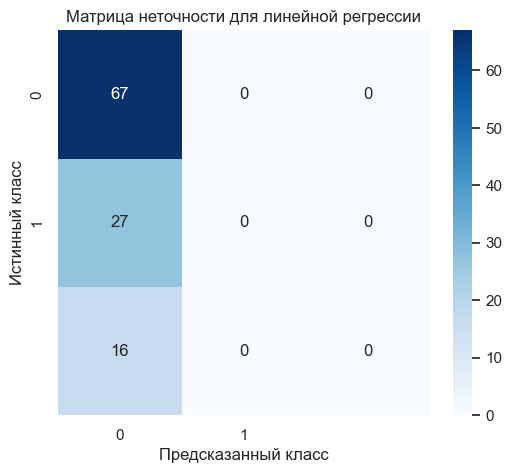

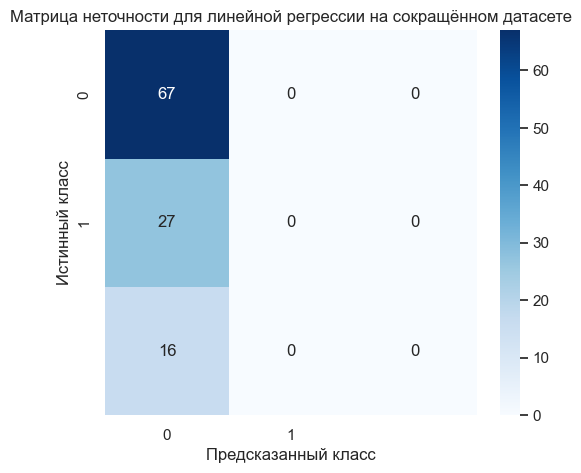

In [17]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lin,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)
plt.title('Матрица неточности для линейной регрессии')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lin_reduced,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)
plt.title('Матрица неточности для линейной регрессии на сокращённом датасете')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

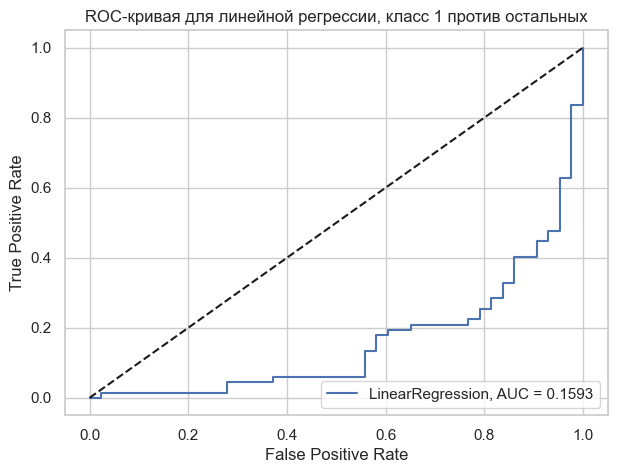

ROC-AUC для линейной регрессии: 0.1593


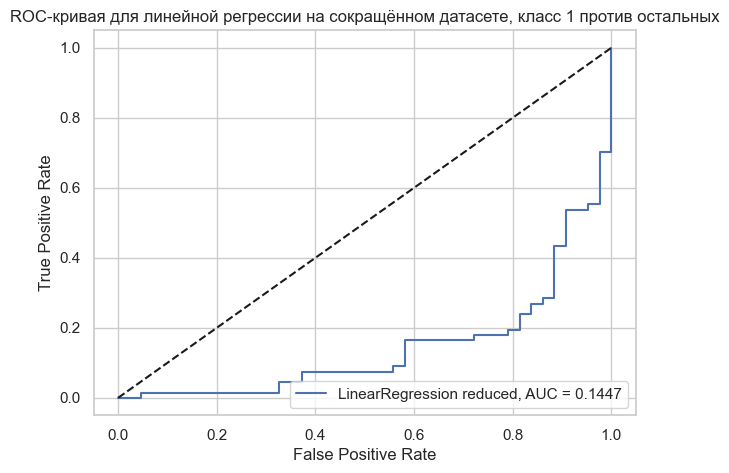

ROC-AUC для линейной регрессии на сокращённом датасете: 0.1447


In [18]:
positive_class = 1

y_test_binary = (y_test == positive_class).astype(int)
y_test_reduced_binary = (y_test_reduced == positive_class).astype(int)

fpr_lin, tpr_lin, thresholds_lin = roc_curve(
    y_test_binary,
    y_pred_lin
)

roc_auc_lin = auc(fpr_lin, tpr_lin)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lin, tpr_lin, label=f'LinearRegression, AUC = {roc_auc_lin:.4f}')
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-кривая для линейной регрессии, класс {positive_class} против остальных')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f'ROC-AUC для линейной регрессии: {roc_auc_lin:.4f}')


fpr_lin_reduced, tpr_lin_reduced, thresholds_lin_reduced = roc_curve(
    y_test_reduced_binary,
    y_pred_lin_reduced
)

roc_auc_lin_reduced = auc(fpr_lin_reduced, tpr_lin_reduced)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr_lin_reduced,
    tpr_lin_reduced,
    label=f'LinearRegression reduced, AUC = {roc_auc_lin_reduced:.4f}'
)
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-кривая для линейной регрессии на сокращённом датасете, класс {positive_class} против остальных')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f'ROC-AUC для линейной регрессии на сокращённом датасете: {roc_auc_lin_reduced:.4f}')

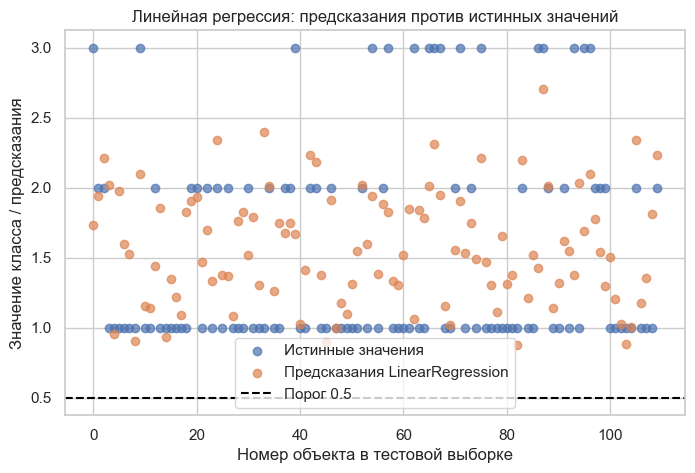

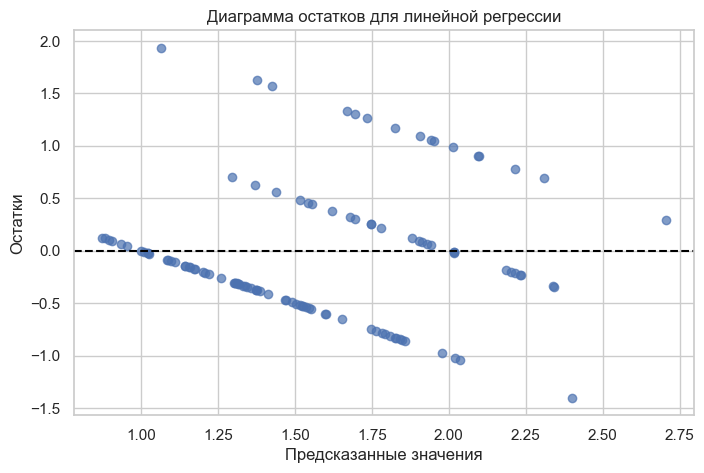

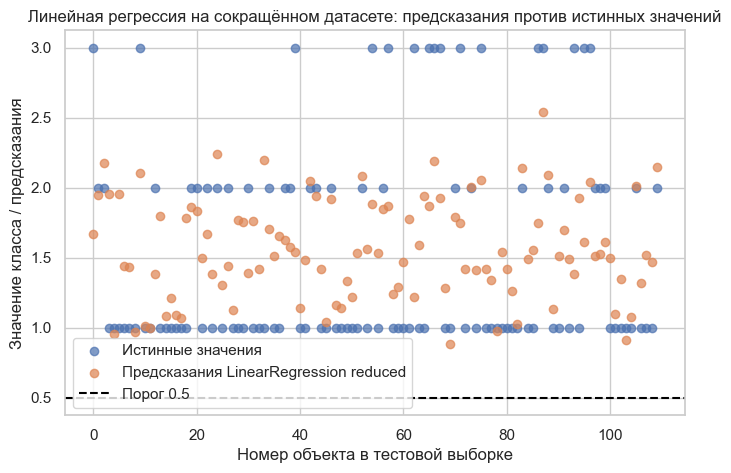

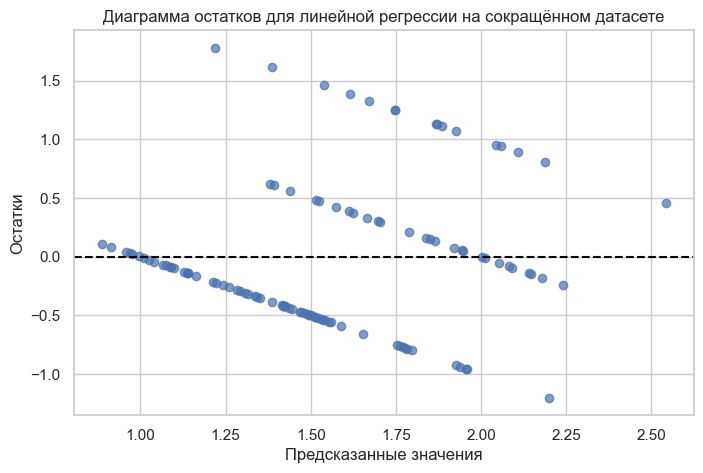

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(range(len(y_test)), y_test, alpha=0.7, label='Истинные значения')
plt.scatter(range(len(y_pred_lin)), y_pred_lin, alpha=0.7, label='Предсказания LinearRegression')
plt.axhline(0.5, linestyle='--', color='black', label='Порог 0.5')
plt.title('Линейная регрессия: предсказания против истинных значений')
plt.xlabel('Номер объекта в тестовой выборке')
plt.ylabel('Значение класса / предсказания')
plt.legend()
plt.show()

residuals_lin = y_test - y_pred_lin
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_lin, residuals_lin, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Диаграмма остатков для линейной регрессии')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(range(len(y_test_reduced)), y_test_reduced, alpha=0.7, label='Истинные значения')
plt.scatter(range(len(y_pred_lin_reduced)), y_pred_lin_reduced, alpha=0.7, label='Предсказания LinearRegression reduced')
plt.axhline(0.5, linestyle='--', color='black', label='Порог 0.5')
plt.title('Линейная регрессия на сокращённом датасете: предсказания против истинных значений')
plt.xlabel('Номер объекта в тестовой выборке')
plt.ylabel('Значение класса / предсказания')
plt.legend()
plt.show()

residuals_lin_reduced = y_test_reduced - y_pred_lin_reduced

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_lin_reduced, residuals_lin_reduced, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Диаграмма остатков для линейной регрессии на сокращённом датасете')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.show()


## 5. Логистическая регрессия. `LogisticRegression`

In [20]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

print('Обученные параметры:')
print(f'Смещение (bias): {log_reg.intercept_[0]:.4f}')
print('Коэффициенты (weights):')
display(pd.Series(log_reg.coef_[0], index=X.columns, name='coef').to_frame())

y_pred_log = log_reg.predict(X_test)
y_pred_log_proba = log_reg.predict_proba(X_test)[:, 1]

accuracy_log = np.mean(y_pred_log == y_test)
print(f'\nТочность логистической регрессии: {accuracy_log:.4f}')

cm_log = confusion_matrix(y_test, y_pred_log)
print('\nМатрица неточности LogisticRegression:')
print(cm_log)

print('\nОтчет по классификации LogisticRegression:')
print(classification_report(y_test, y_pred_log, zero_division=0))

log_reg_reduced = LogisticRegression()
log_reg_reduced.fit(X_train_reduced, y_train_reduced)

print('Обученные параметры LogisticRegression для сокращённого датасета:')
print(f'Смещение (bias): {log_reg_reduced.intercept_[0]:.4f}')
print('Коэффициенты (weights):')
display(pd.Series(log_reg_reduced.coef_[0], index=X_reduced.columns, name='coef').to_frame())

y_pred_log_reduced = log_reg_reduced.predict(X_test_reduced)
y_pred_log_proba_reduced = log_reg_reduced.predict_proba(X_test_reduced)[:, 1]

accuracy_log_reduced = np.mean(y_pred_log_reduced == y_test_reduced)
print(f'\nТочность логистической регрессии для сокращённого датасета: {accuracy_log_reduced:.4f}')

cm_log_reduced = confusion_matrix(y_test_reduced, y_pred_log_reduced)
print('\nМатрица неточности LogisticRegression для сокращённого датасета:')
print(cm_log_reduced)

print('\nОтчет по классификации LogisticRegression для сокращённого датасета:')
print(classification_report(y_test_reduced, y_pred_log_reduced, zero_division=0))

Обученные параметры:
Смещение (bias): 0.0000
Коэффициенты (weights):


C:\Users\sdxop\anaconda3\envs\dnnlab\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,coef
surgery,3.489166e-05
age,8.212541e-06
hospital_number,2.676779e-07
rectal_temperature,7.832572e-04
pulse,6.760007e-04
respiratory_rate,4.796508e-04
temperature_of_extremities,2.977181e-05
peripheral_pulse,1.431158e-05
mucous_membranes,1.948637e-05
capillary_refill_time,1.681873e-05



Точность логистической регрессии: 0.6091

Матрица неточности LogisticRegression:
[[67  0  0]
 [27  0  0]
 [16  0  0]]

Отчет по классификации LogisticRegression:
              precision    recall  f1-score   support

         1.0       0.61      1.00      0.76        67
         2.0       0.00      0.00      0.00        27
         3.0       0.00      0.00      0.00        16

    accuracy                           0.61       110
   macro avg       0.20      0.33      0.25       110
weighted avg       0.37      0.61      0.46       110

Обученные параметры LogisticRegression для сокращённого датасета:
Смещение (bias): 0.0001
Коэффициенты (weights):


C:\Users\sdxop\anaconda3\envs\dnnlab\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,coef
surgery,1.638216e-04
hospital_number,4.559093e-08
rectal_temperature,3.706616e-03
pulse,3.110283e-03
respiratory_rate,2.251011e-03
mucous_membranes,8.530565e-05
pain,1.457959e-04
peristalsis,1.994343e-04
abdominal_distension,9.483468e-05
abdomen,2.833196e-04



Точность логистической регрессии для сокращённого датасета: 0.6091

Матрица неточности LogisticRegression для сокращённого датасета:
[[67  0  0]
 [27  0  0]
 [16  0  0]]

Отчет по классификации LogisticRegression для сокращённого датасета:
              precision    recall  f1-score   support

         1.0       0.61      1.00      0.76        67
         2.0       0.00      0.00      0.00        27
         3.0       0.00      0.00      0.00        16

    accuracy                           0.61       110
   macro avg       0.20      0.33      0.25       110
weighted avg       0.37      0.61      0.46       110



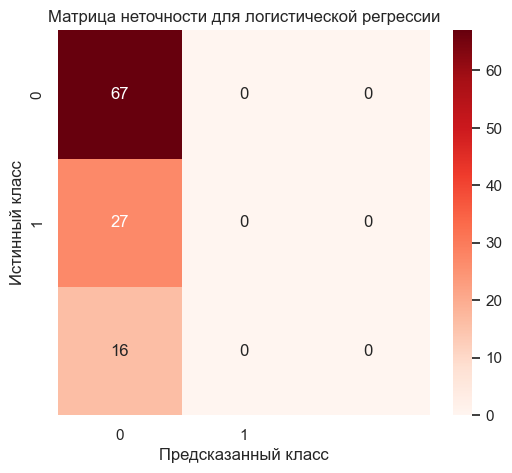

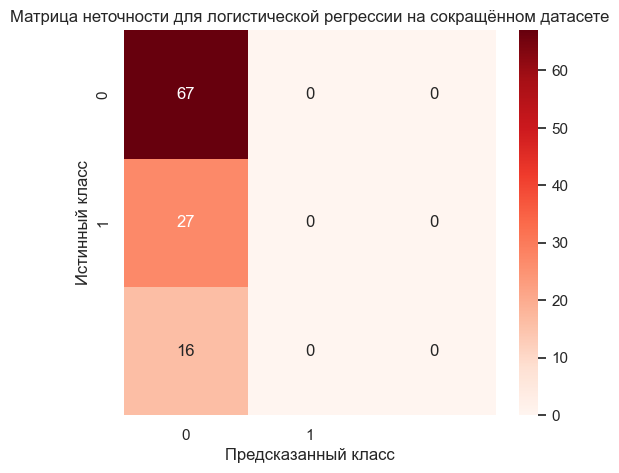

In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)
plt.title('Матрица неточности для логистической регрессии')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_log_reduced,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)
plt.title('Матрица неточности для логистической регрессии на сокращённом датасете')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

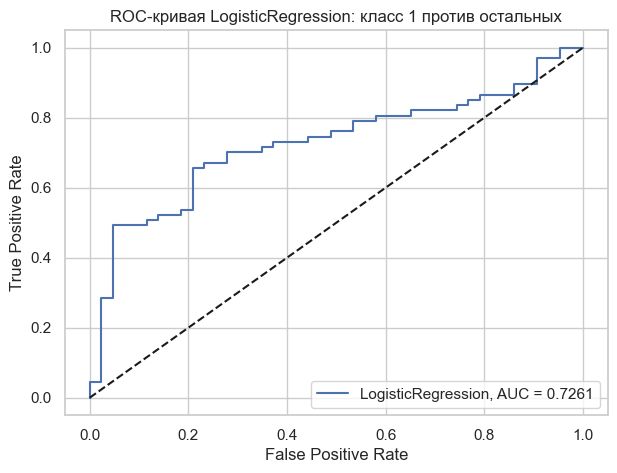

ROC-AUC для логистической регрессии: 0.7261


In [24]:
positive_class = 1

y_test_binary = (y_test == positive_class).astype(int)

# вероятность именно выбранного класса
class_index = list(log_reg.classes_).index(positive_class)
y_pred_log_proba_binary = y_pred_log_proba

fpr_log, tpr_log, thresholds_log = roc_curve(
    y_test_binary,
    y_pred_log_proba_binary
)

roc_auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(7, 5))
plt.plot(fpr_log, tpr_log, label=f'LogisticRegression, AUC = {roc_auc_log:.4f}')
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-кривая LogisticRegression: класс {positive_class} против остальных')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f'ROC-AUC для логистической регрессии: {roc_auc_log:.4f}')

## 6. Сравнение моделей

Сравнение моделей:


,Модель,Точность,ROC-AUC
0,Линейная регрессия,0.609091,0.159320
1,Логистическая регрессия,0.609091,0.726137


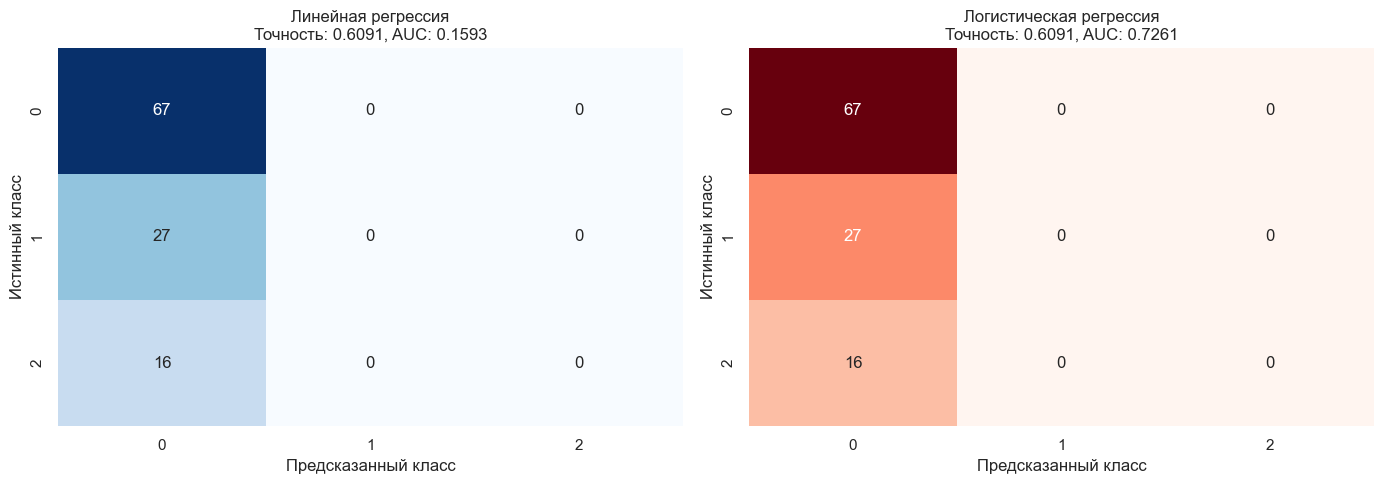

In [25]:
results = pd.DataFrame({
    'Модель': ['Линейная регрессия', 'Логистическая регрессия'],
    'Точность': [accuracy_lin, accuracy_log],
    'ROC-AUC': [roc_auc_lin, roc_auc_log]
})

print('Сравнение моделей:')
display(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_lin, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Линейная регрессия\nТочность: {accuracy_lin:.4f}, AUC: {roc_auc_lin:.4f}')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Reds', ax=axes[1], cbar=False)
axes[1].set_title(f'Логистическая регрессия\nТочность: {accuracy_log:.4f}, AUC: {roc_auc_log:.4f}')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

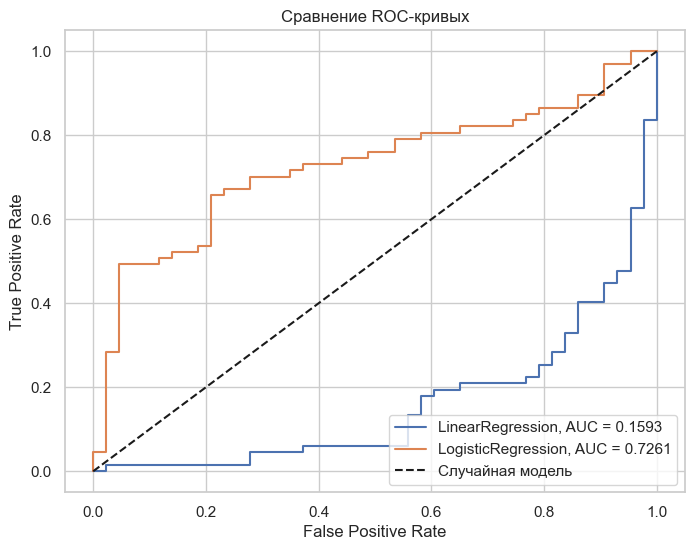

In [26]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_lin, tpr_lin, label=f'LinearRegression, AUC = {roc_auc_lin:.4f}')
plt.plot(fpr_log, tpr_log, label=f'LogisticRegression, AUC = {roc_auc_log:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Сравнение ROC-кривых')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()